   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 5.2 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


CO3 - AT3
COMPARATIVE PERFORMANCE ANALYSIS OF PPO, TRPO AND DDPG

Environment : Pendulum-v1
Observation Space : Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action Space : Box(-2.0, 2.0, (1,), float32)
Training Timesteps : 20000

Training PPO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PPO Completed

Training TRPO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TRPO Completed

Training DDPG...
DDPG Completed


SAMPLE TRAINING DATA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Episode,PPO_Reward,TRPO_Reward,DDPG_Reward
0,1,-1187.130154,-1187.130154,-1185.403278
1,2,-1353.012273,-1422.615031,-1607.840479
2,3,-1295.815304,-1335.627026,-1559.043055
3,4,-1074.759395,-1171.456555,-1581.635674
4,5,-1367.817581,-1530.832103,-1555.415018
5,6,-904.834895,-1045.341384,-1411.238086
6,7,-913.346386,-818.517820,-1326.931238
7,8,-904.291196,-1068.398462,-1223.764494
8,9,-1054.814136,-856.264026,-1062.290461
9,10,-1309.769822,-1472.643774,-1086.032999


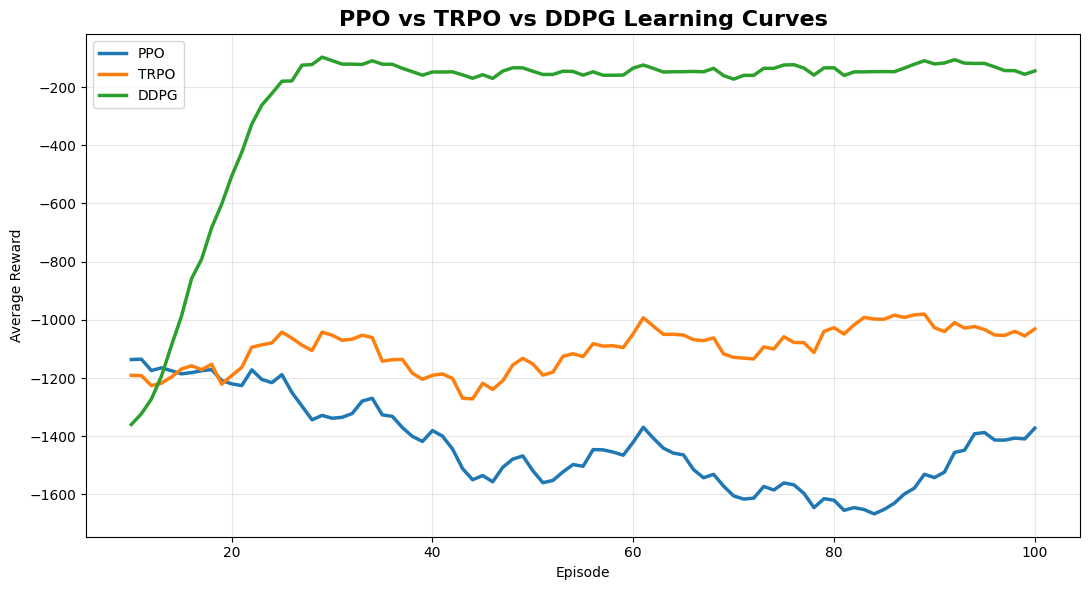

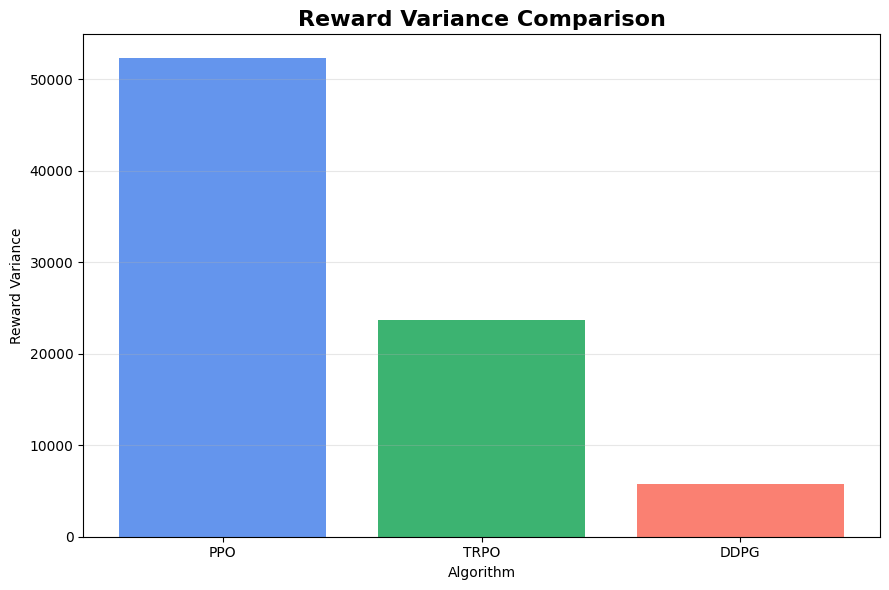

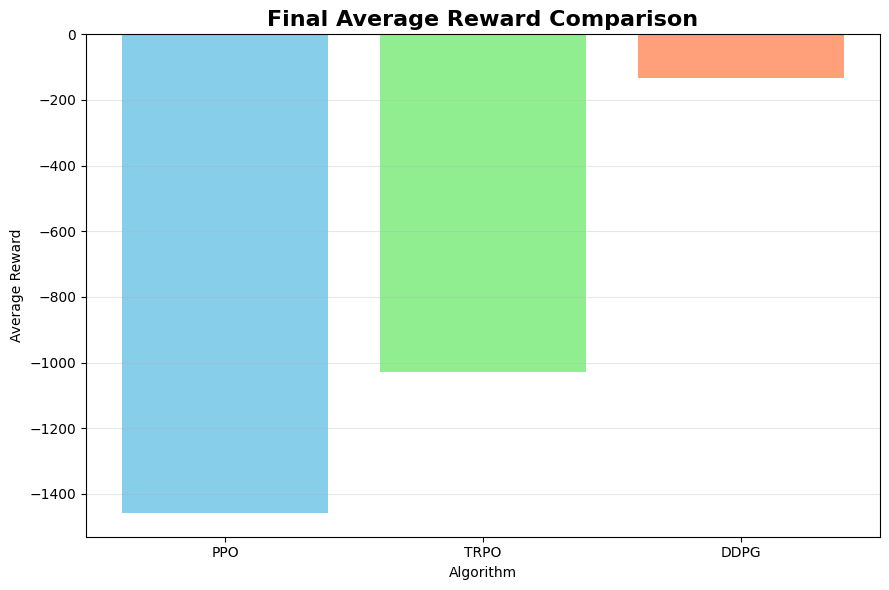

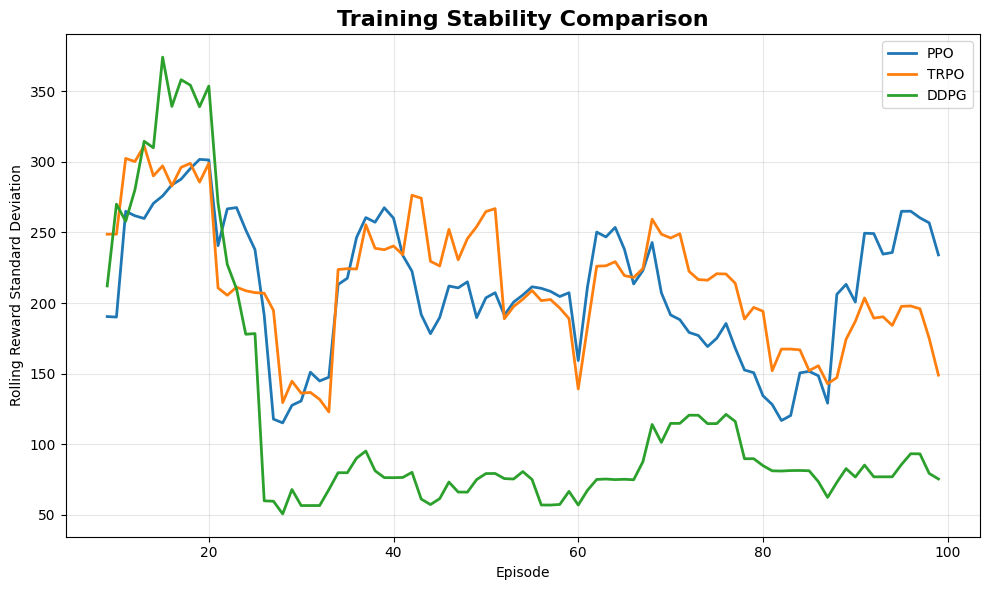

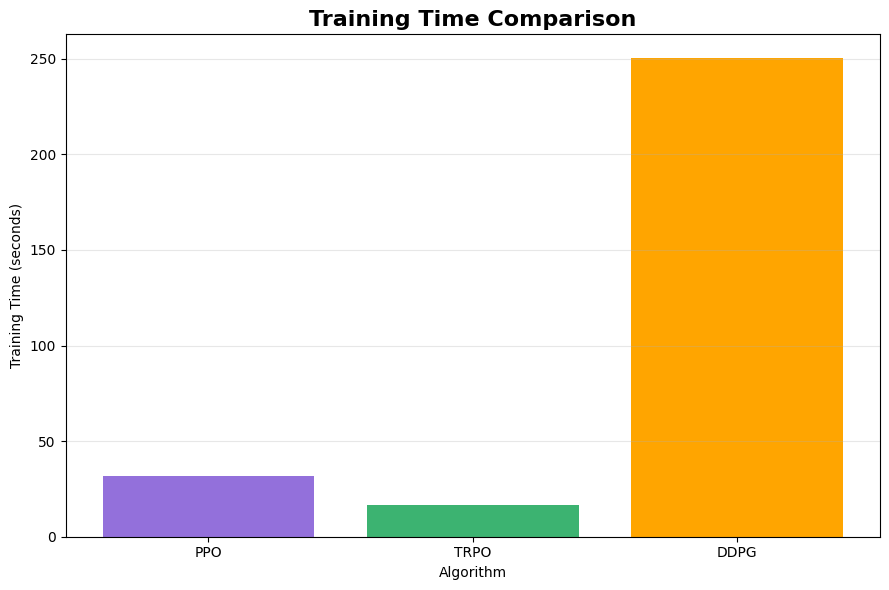



PERFORMANCE SUMMARY


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Algorithm,Final Average Reward,Maximum Reward,Variance,Standard Deviation,Stability,Training Time
0,PPO,-1457.37,-847.43,52321.60,228.74,0.0044,31.841
1,TRPO,-1029.05,-748.28,23658.55,153.81,0.0065,16.433
2,DDPG,-132.41,-0.09,5784.49,76.06,0.0130,250.304




ALGORITHM COMPARISON TABLE


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Metric,PPO,TRPO,DDPG
0,Average Final Reward,-1457.3700,-1029.0500,-132.410
1,Reward Variance,52321.6000,23658.5500,5784.490
2,Stability,0.0044,0.0065,0.013
3,Maximum Reward,-847.4300,-748.2800,-0.090
4,Training Time,31.8410,16.4330,250.304




FINAL RESULTS
Best Final Average Reward : DDPG
Most Stable Algorithm : DDPG
Lowest Reward Variance : DDPG
Fastest Training : TRPO


CONCLUSION
PPO, TRPO and DDPG were implemented and evaluated
using the Pendulum-v1 continuous-control environment.
The algorithms were compared using learning curves,
average reward, variance, stability and training time.
PPO and TRPO are policy optimization methods, while
DDPG is an off-policy actor-critic method designed
for continuous action spaces.
The final experimental results identify the algorithm
with the best reward, stability and training performance.

Generated Files:
1. PPO_TRPO_DDPG_Full_Dataset.csv
2. PPO_TRPO_DDPG_Performance.csv
3. PPO_TRPO_DDPG_Comparison.csv

CO3 - AT3 Completed Successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!pip -q install stable-baselines3 sb3-contrib gymnasium

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import time
from stable_baselines3 import PPO, DDPG
from sb3_contrib import TRPO
from stable_baselines3.common.callbacks import BaseCallback

np.random.seed(42)

print("="*80)
print("CO3 - AT3")
print("COMPARATIVE PERFORMANCE ANALYSIS OF PPO, TRPO AND DDPG")
print("="*80)

env_name = "Pendulum-v1"
total_timesteps = 20000

env = gym.make(env_name)

print("\nEnvironment :", env_name)
print("Observation Space :", env.observation_space)
print("Action Space :", env.action_space)
print("Training Timesteps :", total_timesteps)

class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards = []
        self.episodes = []
        self.steps = []
        self.current_reward = 0

    def _on_step(self):
        reward = float(self.locals["rewards"][0])
        self.current_reward += reward

        if self.locals["dones"][0]:
            self.rewards.append(self.current_reward)
            self.episodes.append(len(self.rewards))
            self.steps.append(self.num_timesteps)
            self.current_reward = 0

        return True

def train_algorithm(name):

    train_env = gym.make(env_name)

    callback = RewardCallback()

    start = time.time()

    if name == "PPO":
        model = PPO(
            "MlpPolicy",
            train_env,
            learning_rate=0.0003,
            n_steps=256,
            batch_size=64,
            gamma=0.99,
            verbose=0,
            seed=42
        )

    elif name == "TRPO":
        model = TRPO(
            "MlpPolicy",
            train_env,
            learning_rate=0.0003,
            gamma=0.99,
            verbose=0,
            seed=42
        )

    else:
        model = DDPG(
            "MlpPolicy",
            train_env,
            learning_rate=0.001,
            buffer_size=10000,
            batch_size=64,
            gamma=0.99,
            verbose=0,
            seed=42
        )

    model.learn(
        total_timesteps=total_timesteps,
        callback=callback
    )

    training_time = time.time() - start

    train_env.close()

    return model, callback, training_time

print("\nTraining PPO...")
ppo_model, ppo_callback, ppo_time = train_algorithm("PPO")
print("PPO Completed")

print("\nTraining TRPO...")
trpo_model, trpo_callback, trpo_time = train_algorithm("TRPO")
print("TRPO Completed")

print("\nTraining DDPG...")
ddpg_model, ddpg_callback, ddpg_time = train_algorithm("DDPG")
print("DDPG Completed")

ppo_rewards = ppo_callback.rewards
trpo_rewards = trpo_callback.rewards
ddpg_rewards = ddpg_callback.rewards

min_length = min(
    len(ppo_rewards),
    len(trpo_rewards),
    len(ddpg_rewards)
)

ppo_rewards = ppo_rewards[:min_length]
trpo_rewards = trpo_rewards[:min_length]
ddpg_rewards = ddpg_rewards[:min_length]

episodes = np.arange(
    1,
    min_length + 1
)

results = pd.DataFrame({
    "Episode": episodes,
    "PPO_Reward": ppo_rewards,
    "TRPO_Reward": trpo_rewards,
    "DDPG_Reward": ddpg_rewards
})

print("\n")
print("="*80)
print("SAMPLE TRAINING DATA")
print("="*80)

display(results.head(10))

results.to_csv(
    "PPO_TRPO_DDPG_Full_Dataset.csv",
    index=False
)

window = 10

ppo_smooth = results["PPO_Reward"].rolling(
    window
).mean()

trpo_smooth = results["TRPO_Reward"].rolling(
    window
).mean()

ddpg_smooth = results["DDPG_Reward"].rolling(
    window
).mean()

plt.figure(figsize=(11,6))

plt.plot(
    episodes,
    ppo_smooth,
    label="PPO",
    linewidth=2.5
)

plt.plot(
    episodes,
    trpo_smooth,
    label="TRPO",
    linewidth=2.5
)

plt.plot(
    episodes,
    ddpg_smooth,
    label="DDPG",
    linewidth=2.5
)

plt.title(
    "PPO vs TRPO vs DDPG Learning Curves",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ppo_variance = np.var(
    ppo_rewards[-20:]
)

trpo_variance = np.var(
    trpo_rewards[-20:]
)

ddpg_variance = np.var(
    ddpg_rewards[-20:]
)

plt.figure(figsize=(9,6))

plt.bar(
    ["PPO","TRPO","DDPG"],
    [
        ppo_variance,
        trpo_variance,
        ddpg_variance
    ],
    color=[
        "cornflowerblue",
        "mediumseagreen",
        "salmon"
    ]
)

plt.title(
    "Reward Variance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Algorithm")
plt.ylabel("Reward Variance")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

ppo_avg = np.mean(
    ppo_rewards[-20:]
)

trpo_avg = np.mean(
    trpo_rewards[-20:]
)

ddpg_avg = np.mean(
    ddpg_rewards[-20:]
)

plt.figure(figsize=(9,6))

plt.bar(
    ["PPO","TRPO","DDPG"],
    [
        ppo_avg,
        trpo_avg,
        ddpg_avg
    ],
    color=[
        "skyblue",
        "lightgreen",
        "lightsalmon"
    ]
)

plt.title(
    "Final Average Reward Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Algorithm")
plt.ylabel("Average Reward")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))

plt.plot(
    results["PPO_Reward"].rolling(10).std(),
    label="PPO",
    linewidth=2
)

plt.plot(
    results["TRPO_Reward"].rolling(10).std(),
    label="TRPO",
    linewidth=2
)

plt.plot(
    results["DDPG_Reward"].rolling(10).std(),
    label="DDPG",
    linewidth=2
)

plt.title(
    "Training Stability Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Rolling Reward Standard Deviation")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))

plt.bar(
    ["PPO","TRPO","DDPG"],
    [
        ppo_time,
        trpo_time,
        ddpg_time
    ],
    color=[
        "mediumpurple",
        "mediumseagreen",
        "orange"
    ]
)

plt.title(
    "Training Time Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Algorithm")
plt.ylabel("Training Time (seconds)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

final_window = 20

ppo_final = np.mean(
    ppo_rewards[-final_window:]
)

trpo_final = np.mean(
    trpo_rewards[-final_window:]
)

ddpg_final = np.mean(
    ddpg_rewards[-final_window:]
)

ppo_std = np.std(
    ppo_rewards[-final_window:]
)

trpo_std = np.std(
    trpo_rewards[-final_window:]
)

ddpg_std = np.std(
    ddpg_rewards[-final_window:]
)

ppo_stability = 1 / (
    1 + ppo_std
)

trpo_stability = 1 / (
    1 + trpo_std
)

ddpg_stability = 1 / (
    1 + ddpg_std
)

performance = pd.DataFrame({

    "Algorithm": [
        "PPO",
        "TRPO",
        "DDPG"
    ],

    "Final Average Reward": [
        round(ppo_final,2),
        round(trpo_final,2),
        round(ddpg_final,2)
    ],

    "Maximum Reward": [
        round(np.max(ppo_rewards),2),
        round(np.max(trpo_rewards),2),
        round(np.max(ddpg_rewards),2)
    ],

    "Variance": [
        round(ppo_variance,2),
        round(trpo_variance,2),
        round(ddpg_variance,2)
    ],

    "Standard Deviation": [
        round(ppo_std,2),
        round(trpo_std,2),
        round(ddpg_std,2)
    ],

    "Stability": [
        round(ppo_stability,4),
        round(trpo_stability,4),
        round(ddpg_stability,4)
    ],

    "Training Time": [
        round(ppo_time,3),
        round(trpo_time,3),
        round(ddpg_time,3)
    ]
})

print("\n")
print("="*80)
print("PERFORMANCE SUMMARY")
print("="*80)

display(performance)

performance.to_csv(
    "PPO_TRPO_DDPG_Performance.csv",
    index=False
)

learning_comparison = pd.DataFrame({

    "Metric": [
        "Average Final Reward",
        "Reward Variance",
        "Stability",
        "Maximum Reward",
        "Training Time"
    ],

    "PPO": [
        round(ppo_final,2),
        round(ppo_variance,2),
        round(ppo_stability,4),
        round(np.max(ppo_rewards),2),
        round(ppo_time,3)
    ],

    "TRPO": [
        round(trpo_final,2),
        round(trpo_variance,2),
        round(trpo_stability,4),
        round(np.max(trpo_rewards),2),
        round(trpo_time,3)
    ],

    "DDPG": [
        round(ddpg_final,2),
        round(ddpg_variance,2),
        round(ddpg_stability,4),
        round(np.max(ddpg_rewards),2),
        round(ddpg_time,3)
    ]
})

print("\n")
print("="*80)
print("ALGORITHM COMPARISON TABLE")
print("="*80)

display(learning_comparison)

learning_comparison.to_csv(
    "PPO_TRPO_DDPG_Comparison.csv",
    index=False
)

best_algorithm = performance.loc[
    performance["Final Average Reward"].idxmax(),
    "Algorithm"
]

most_stable = performance.loc[
    performance["Stability"].idxmax(),
    "Algorithm"
]

lowest_variance = performance.loc[
    performance["Variance"].idxmin(),
    "Algorithm"
]

fastest_algorithm = performance.loc[
    performance["Training Time"].idxmin(),
    "Algorithm"
]

print("\n")
print("="*80)
print("FINAL RESULTS")
print("="*80)

print(
    "Best Final Average Reward :",
    best_algorithm
)

print(
    "Most Stable Algorithm :",
    most_stable
)

print(
    "Lowest Reward Variance :",
    lowest_variance
)

print(
    "Fastest Training :",
    fastest_algorithm
)

print("\n")
print("="*80)
print("CONCLUSION")
print("="*80)

print(
    "PPO, TRPO and DDPG were implemented and evaluated"
)

print(
    "using the Pendulum-v1 continuous-control environment."
)

print(
    "The algorithms were compared using learning curves,"
)

print(
    "average reward, variance, stability and training time."
)

print(
    "PPO and TRPO are policy optimization methods, while"
)

print(
    "DDPG is an off-policy actor-critic method designed"
)

print(
    "for continuous action spaces."
)

print(
    "The final experimental results identify the algorithm"
)

print(
    "with the best reward, stability and training performance."
)

print("\nGenerated Files:")
print("1. PPO_TRPO_DDPG_Full_Dataset.csv")
print("2. PPO_TRPO_DDPG_Performance.csv")
print("3. PPO_TRPO_DDPG_Comparison.csv")

print("\nCO3 - AT3 Completed Successfully.")

In [2]:
from google.colab import files
files.download("PPO_TRPO_DDPG_Full_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>